# Hiperparámetros — AC CTRL → Intercambiador de Calor
Búsqueda de hiperparámetros + corrida larga para el caso SISO del intercambiador de calor.

**Sistema:** FOPDT (primer orden + tiempo muerto)
- Variable controlada: T_out (temperatura de salida, °C — variables desviación)
- Variable manipulable: M (señal de control, 4-20 mA)
- K=11.2455 °C/mA, τ=0.405 min, θ=0.125 min

**Referencia:** Trabajo Final — Dinámica y Control de Procesos (2013)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1815, done.
remote: Counting objects: 100% (375/375), done.
remote: Compressing objects: 100% (251/251), done.
remote: Total 1815 (delta 227), reused 265 (delta 123), pack-reused 1440 (from 1)
Receiving objects: 100% (1815/1815), 54.13 MiB | 20.71 MiB/s, done.
Resolving deltas: 100% (1091/1091), done.


In [3]:
from Environment.Simulation_Env.Heat_Exchanger import HeatExchangerSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.Simulation_Env.SimulationEnv import SimulationPIDEnv
from Agente.Actor_Critic.train_AC import ACTrainer
from Agente.Actor_Critic.algorithm_AC import ACAgent
from Agente.memory import SimpleReplayBuffer
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


## 2. Sweep de Hiperparámetros con W&B

Se exploran combinaciones de learning rates, arquitectura de red, coeficiente de entropía
y pesos de reward para encontrar la mejor configuración para el intercambiador SISO.

In [4]:
# ============ CONSTANTES DEL PROCESO ============
N_MANIPULABLE_VARS = 1
MANIPULABLE_RANGES = [(-50.0, 50.0)]          # T_out en variables desviación (°C)
ACTUATOR_LIMITS = [(-8.0, 8.0)]               # Señal de control M en variables desviación (mA)
                                               # Absoluto: 4-20 mA, SS=12 mA → desviación: ±8 mA
DT = 0.125                                     # min (= tiempo muerto θ)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_AC_HeatExchanger_Sweep_v2'  # Nuevo proyecto para el re-sweep

In [5]:
# ============ CONFIGURACIÓN DEL SWEEP ============
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'best_eval_reward', 'goal': 'maximize'},
    'parameters': {
        'lr_actor':      {'values': [1e-05, 3e-05, 1e-04, 3e-04]},
        'lr_critic':     {'values': [1e-04, 5e-04, 1e-03, 5e-03]},
        'entropy_coef':  {'values': [0.001, 0.005, 0.01, 0.05]},
        'hidden_dims':   {'values': ['256_128_64', '128_64_32', '128_64', '64_32']},
        'gamma':         {'values': [0.95, 0.99]},
        'batch_size':    {'values': [64, 128]},
        'buffer_size':   {'values': [10000, 50000]},
        'max_steps':     {'values': [50, 100]},
        'reward_error_w':    {'values': [1.0, 3.0, 5.0]},
        'reward_overshoot_w': {'values': [0.1, 1.0, 5.0]},
        'reward_time_w':     {'values': [0.0, 0.001, 0.01]},
        'delta_percent_ctrl': {'values': [0.05, 0.10, 0.20]},
    },
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print(f'Sweep creado: {sweep_id}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: ylup1qm8
Sweep URL: https://wandb.ai/ve326684-universidad-ort-uruguay/Tesis_AC_HeatExchanger_Sweep_v2/sweeps/ylup1qm8
Sweep creado: ylup1qm8


In [6]:
# ============ FUNCIÓN DE ENTRENAMIENTO PARA EL SWEEP ============
def train_sweep():
    run = wandb.init()
    config = wandb.config

    # Parsear hidden_dims
    hidden_dims = tuple(int(x) for x in config.hidden_dims.split('_'))

    N_EPISODES_SWEEP = 500  # Episodios cortos para explorar rápido
    RUN_NAME = f'sweep_{run.name}'

    trainer_config = {
        'env_config': {
            'architecture':          'simple',
            'env_type':              'simulation',
            'action_type':           'continuous',
            'n_manipulable_vars':    N_MANIPULABLE_VARS,
            'manipulable_ranges':    MANIPULABLE_RANGES,
            'manipulable_setpoints': None,
            'dt_usuario':            DT,
            'max_steps':             config.max_steps,
            'max_time_detector':     3.0,
            'reward_dead_band':      0.05,
            'delta_percent_ctrl':    config.delta_percent_ctrl,
            'reward_weights': {
                'error':     config.reward_error_w,
                'tiempo':    config.reward_time_w,
                'overshoot': config.reward_overshoot_w,
                'energy':    0.0,
            },
            'pid_limits':            [(0.001, 5.0), (0.0, 50.0), (0.0, 1.0)],  # Rangos PID más acotados para SISO FOPDT
            'agent_controller_config': {'agent_type': 'continuous'},
            'env_type_config': {
                'dt': DT,
                'control_limits': (ACTUATOR_LIMITS[0],)
            },
            'stability_config': {
                'error_increase_tolerance': 2.0,
                'max_sign_changes_ratio':   0.3,
                'max_abrupt_change_ratio':  0.05,
                'abrupt_change_threshold':  0.5,
            },
        },
        'agent_ctrl_config': {
            'algorithm':    'ac',
            'state_dim':    5,       # SISO: [pv, sp, error, integral, derivative]
            'action_dim':   3,       # SISO: [Kp, Ki, Kd] para 1 PID
            'n_vars':       1,
            'action_type':  'continuous',
            'hidden_dims':  hidden_dims,
            'lr_actor':     config.lr_actor,
            'lr_critic':    config.lr_critic,
            'gamma':        config.gamma,
            'entropy_coef': config.entropy_coef,
            'batch_size':   config.batch_size,
            'buffer_size':  config.buffer_size,
            'warmup_steps': 200,
            'device':       DEVICE,
            'seed':         SEED,
        },
        'n_episodes':                    N_EPISODES_SWEEP,
        'eval_frequency':                50,
        'log_frequency':                 50,
        'save_frequency':                500,
        'checkpoint_dir':                f'checkpoints/{RUN_NAME}',
        'early_stopping_patience':       15,
        'early_stopping_min_delta_pct':  0.01,
        'use_wandb': True,
    }

    try:
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)

        hx = HeatExchangerSimulator(
            dt=DT,
            control_limits=(ACTUATOR_LIMITS[0],)
        )
        trainer = ACTrainer(trainer_config)
        trainer.env.proceso.connect_external_process(hx)
        trainer.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]

        # PID bias: en variables desviación el SS es 0, no hay bias
        # Pero inicializamos con Kp razonable para arrancar estable
        _original_reset = trainer.env.reset
        def reset_with_init(*args, **kwargs):
            result = _original_reset(*args, **kwargs)
            pid = trainer.env.pid_controllers[0]
            pid.kp = 0.1
            pid.ki = 0.5
            pid.kd = 0.0
            pid.integral = 0.0  # SS en variables desviación = 0
            return result
        trainer.env.reset = reset_with_init

        trainer.train()

        wandb.log({
            'best_eval_reward': trainer.best_reward,
            'total_episodes': len(trainer.episode_rewards),
        })
    except Exception as e:
        print(f'Error en sweep: {e}')
        wandb.log({'best_eval_reward': -999, 'error': str(e)})
    finally:
        wandb.finish()

In [7]:
# ============ EJECUTAR SWEEP ============
wandb.agent(sweep_id, function=train_sweep, count=25, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print('Sweep completado')

wandb: Agent Starting Run: 10rh2m6b with config:
wandb: 	batch_size: 128
wandb: 	buffer_size: 50000
wandb: 	delta_percent_ctrl: 0.05
wandb: 	entropy_coef: 0.05
wandb: 	gamma: 0.95
wandb: 	hidden_dims: 256_128_64
wandb: 	lr_actor: 0.0001
wandb: 	lr_critic: 0.005
wandb: 	max_steps: 50
wandb: 	reward_error_w: 1
wandb: 	reward_overshoot_w: 5
wandb: 	reward_time_w: 0.01
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


AC Estocástico creado | role=ctrl | state=5 | action=3 | device=cuda

Episodio 0/500
  Reward: -0.25 | Length: 51
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Advantage mean: 0.0000

Episodio 50/500
  Reward: -0.23 | Length: 51
  Actor Loss: -14.0899 | Critic Loss: 8.8987
  Advantage mean: 0.0234


wandb: Adding directory to artifact (checkpoints/sweep_comfy-sweep-1)... Done. 0.0s


Evaluación: Reward promedio = -0.37
AC Agent guardado en: checkpoints/sweep_comfy-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/500
  Reward: -0.18 | Length: 51
  Actor Loss: -77.2319 | Critic Loss: 6.9314
  Advantage mean: -0.0013


wandb: Adding directory to artifact (checkpoints/sweep_comfy-sweep-1)... Done. 0.0s


...

Evaluación: Reward promedio = -0.08
  Sin mejora: 1/15
AC Agent guardado en: checkpoints/sweep_soft-sweep-25/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/500
  Reward: -0.13 | Length: 101
  Actor Loss: -1.3075 | Critic Loss: 1.1949
  Advantage mean: -0.0071


wandb: Adding directory to artifact (checkpoints/sweep_soft-sweep-25)... Done. 0.0s


Evaluación: Reward promedio = -0.04
AC Agent guardado en: checkpoints/sweep_soft-sweep-25/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/500
  Reward: -0.05 | Length: 101
  Actor Loss: -1.7964 | Critic Loss: 1.0070
  Advantage mean: -0.0095
Evaluación: Reward promedio = -0.12
  Sin mejora: 1/15

Episodio 250/500
  Reward: -0.21 | Length: 101
  Actor Loss: -1.4828 | Critic Loss: 0.8998
  Advantage mean: -0.0025
Evaluación: Reward promedio = -0.14
  Sin mejora: 2/15

Episodio 300/500
  Reward: -0.03 | Length: 101
  Actor Loss: -1.0709 | Critic Loss: 0.8153
  Advantage mean: 0.0048
Evaluación: Reward promedio = -0.08
  Sin mejora: 3/15

Episodio 350/500
  Reward: -0.00 | Length: 101
  Actor Loss: -1.0513 | Critic Loss: 0.5461
  Advantage mean: -0.0008
Evaluación: Reward promedio = -0.13
  Sin mejora: 4/15

Episodio 400/500
  Reward: -0.04 | Length: 101
  Actor Loss: 0.1758 | Critic Loss: 0.6810
  Advantage mean: 0.0112
Evaluación: Reward promedio = -0.05
  Sin mejora: 5/15

Ep

actor_loss,█▃▁▁▂▂▂▃▂▃▂▂▂▃▃▃▃▂▂▂▂▂▃▃▃▃▂▃▃▂▃▃▃▃▃▃▂▂▃▃
best_eval_reward,▁
critic_loss,▁█▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
energy,▇▆▇▇▇▂▄▃▄▄▇▇▄▃▁▂█▄▃▅▇▆█▂▁▁█▁▄▄█▁▁▅▁█▃▂▂▂
eval_reward,▅▅█▂▁▅▂▇▁
kd_var0,▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ki_var0,▁▁▁▁▅▁▆▄█▁▃▅█▁▁▂▃▁▁▁▁▁▁▁▁█▁▆██▁▁▁▁▅▂▁▁▄▁
kp_var0,▁█▆▃▇█▆▇█▁█▁▁█▁▂█▃█▆▄█▃█▂▁█▁▅▁▁▇▁▁█▁▁▁▁█
overshoot,▁▂▂▁▁▁▃▄▂▁▃▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▄▁▁▂▄▁▁▄▁█
reward,▁█▄▇▅▇█▄▇▅▆▃▆▇█▆▅▇▆▄▅▅▇▄▆▄█▇▅▅▇▅▇▆▇▇▇▆██
+1,...


Sweep completado


## 3. Análisis del Sweep

In [5]:
# ============ OBTENER RESULTADOS DEL SWEEP ============
api = wandb.Api()
sweep = api.sweep(f've326684-universidad-ort-uruguay/Tesis_AC_HeatExchanger_Sweep_v2/ylup1qm8')

runs_data = []
for run in sweep.runs:
    if run.state == 'finished':
        runs_data.append({
            'name': run.name,
            'best_reward': run.summary.get('best_eval_reward', -999),
            'lr_actor': run.config.get('lr_actor'),
            'lr_critic': run.config.get('lr_critic'),
            'entropy_coef': run.config.get('entropy_coef'),
            'hidden_dims': run.config.get('hidden_dims'),
            'gamma': run.config.get('gamma'),
            'batch_size': run.config.get('batch_size'),
            'max_steps': run.config.get('max_steps'),
            'reward_error_w': run.config.get('reward_error_w'),
            'reward_overshoot_w': run.config.get('reward_overshoot_w'),
            'delta_percent_ctrl': run.config.get('delta_percent_ctrl'),
        })

df = pd.DataFrame(runs_data).sort_values('best_reward', ascending=False)
print('=== TOP 10 RUNS ===')
print(df.head(10).to_string(index=False))
print(f'\nMejor run: {df.iloc[0]["name"]} con reward={df.iloc[0]["best_reward"]:.4f}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


=== TOP 10 RUNS ===
               name  best_reward  lr_actor  lr_critic  entropy_coef hidden_dims  gamma  batch_size  max_steps  reward_error_w  reward_overshoot_w  delta_percent_ctrl
      soft-sweep-25    -0.038875   0.00001     0.0005          0.01       64_32   0.99         128        100               1                 0.1                0.05
effortless-sweep-23    -0.046825   0.00003     0.0010          0.05      128_64   0.95         128         50               1                 0.1                0.05
     pious-sweep-13    -0.063662   0.00010     0.0005          0.05  256_128_64   0.95         128        100               1                 0.1                0.05
   ethereal-sweep-8    -0.066995   0.00010     0.0005          0.05  256_128_64   0.95         128         50               1                 1.0                0.05
     prime-sweep-19    -0.074346   0.00030     0.0005          0.05  256_128_64   0.95          64         50               1                 0.1     

In [6]:
# ============ EXTRAER MEJOR CONFIGURACIÓN ============
best = df.iloc[0]
print('\n=== MEJOR CONFIGURACIÓN ===')
for col in df.columns:
    if col != 'name':
        print(f'  {col}: {best[col]}')

BEST_HIDDEN_DIMS = tuple(int(x) for x in best['hidden_dims'].split('_'))
print(f'\nhidden_dims parseado: {BEST_HIDDEN_DIMS}')


=== MEJOR CONFIGURACIÓN ===
  best_reward: -0.03887476997306918
  lr_actor: 1e-05
  lr_critic: 0.0005
  entropy_coef: 0.01
  hidden_dims: 64_32
  gamma: 0.99
  batch_size: 128
  max_steps: 100
  reward_error_w: 1
  reward_overshoot_w: 0.1
  delta_percent_ctrl: 0.05

hidden_dims parseado: (64, 32)


## 4. Corrida Larga con la Mejor Configuración

Usando los hiperparámetros ganadores del sweep, entrenamos por 5000 episodios.

In [22]:
# ============ CONFIG PRODUCCIÓN — del sweep ganador ============
WANDB_PROJECT_PROD = 'Tesis_AC_HeatExchanger_Prod_v3'
RUN_NAME = 'ac_heatexchanger_5k'

N_EPISODES = 5000
EVAL_FREQUENCY = 100
LOG_FREQUENCY = 100
SAVE_FREQUENCY = 1000
EARLY_STOPPING_PATIENCE = 20

trainer_config_prod = {
    'env_config': {
        'architecture':          'simple',
        'env_type':              'simulation',
        'action_type':           'continuous',
        'n_manipulable_vars':    N_MANIPULABLE_VARS,
        'manipulable_ranges':    MANIPULABLE_RANGES,
        'manipulable_setpoints': None,
        'dt_usuario':            DT,
        'max_steps':             int(best['max_steps']),
        'max_time_detector':     3.0,
        'reward_dead_band':      0.05,
        'delta_percent_ctrl':    float(best['delta_percent_ctrl']),
        'reward_weights': {
            'error':     float(best['reward_error_w']),
            'tiempo':    0.001,
            'overshoot': float(best['reward_overshoot_w']),
            'energy':    0.0,
        },
        'pid_limits':             [(0.005, 0.2), (0.0, 0.5), (0.0, 0.1)],  # Rangos PID más acotados para SISO FOPDT
        'agent_controller_config': {'agent_type': 'continuous'},
        'env_type_config': {
            'dt': DT,
            'control_limits': (ACTUATOR_LIMITS[0],)
        },
        'stability_config': {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio':   0.3,
            'max_abrupt_change_ratio':  0.05,
            'abrupt_change_threshold':  0.5,
        },
    },
    'agent_ctrl_config': {
        'algorithm':    'ac',
        'state_dim':    5,
        'action_dim':   3,
        'n_vars':       1,
        'action_type':  'continuous',
        'hidden_dims':  BEST_HIDDEN_DIMS,
        'lr_actor':     float(best['lr_actor']),
        'lr_critic':    float(best['lr_critic']),
        'gamma':        float(best['gamma']),
        'entropy_coef': float(best['entropy_coef']),
        'batch_size':   int(best['batch_size']),
        'buffer_size':  50000,
        'warmup_steps': 500,
        'device':       DEVICE,
        'seed':         SEED,
    },
    'n_episodes':                    N_EPISODES,
    'eval_frequency':                EVAL_FREQUENCY,
    'log_frequency':                 LOG_FREQUENCY,
    'save_frequency':                SAVE_FREQUENCY,
    'checkpoint_dir':                f'checkpoints/{RUN_NAME}',
    'early_stopping_patience':       EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct':  0.01,
    'use_wandb': True,
}

In [23]:
# ============ CREAR ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

hx_prod = HeatExchangerSimulator(
    dt=DT,
    control_limits=(ACTUATOR_LIMITS[0],)
)
trainer_prod = ACTrainer(trainer_config_prod)
trainer_prod.env.proceso.connect_external_process(hx_prod)
trainer_prod.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]

AC Estocástico creado | role=ctrl | state=5 | action=3 | device=cuda


In [24]:
# ============ FIX: PID inicialización ============
_original_reset = trainer_prod.env.reset

def reset_with_init(*args, **kwargs):
    result = _original_reset(*args, **kwargs)
    pid = trainer_prod.env.pid_controllers[0]
    pid.kp = 0.05
    pid.ki = 0.1
    pid.kd = 0.0
    pid.integral = 0.0  # Variables desviación: SS = 0
    return result

trainer_prod.env.reset = reset_with_init
print('PID inicialización configurada (variables desviación, SS=0)')

PID inicialización configurada (variables desviación, SS=0)


In [25]:
# ============ ENTRENAR ============
wandb.init(
    project=WANDB_PROJECT_PROD, entity=WANDB_ENTITY,
    name=RUN_NAME,
    tags=['ac', 'produccion', 'heat_exchanger', 'from_scratch'],
    config=trainer_config_prod,
)

trainer_prod.train()

wandb.log({
    'final_eval_reward': trainer_prod.best_reward,
    'total_episodes': len(trainer_prod.episode_rewards),
})
wandb.finish()
print(f'Producción completada: {RUN_NAME}')


Episodio 0/5000
  Reward: -0.01 | Length: 101
  Actor Loss: 0.0000 | Critic Loss: 0.0000
  Advantage mean: 0.0000

Episodio 100/5000
  Reward: -0.01 | Length: 101
  Actor Loss: -2.2330 | Critic Loss: 1.2117
  Advantage mean: 0.0126


wandb: Adding directory to artifact (checkpoints/ac_heatexchanger_5k)... Done. 0.0s


Evaluación: Reward promedio = -0.01
AC Agent guardado en: checkpoints/ac_heatexchanger_5k/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/5000
  Reward: -0.00 | Length: 101
  Actor Loss: -1.1494 | Critic Loss: 0.8189
  Advantage mean: 0.0158


wandb: Adding directory to artifact (checkpoints/ac_heatexchanger_5k)... Done. 0.0s


Evaluación: Reward promedio = -0.00
  Sin mejora: 1/20
AC Agent guardado en: checkpoints/ac_heatexchanger_5k/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 300/5000
  Reward: -0.00 | Length: 101
  Actor Loss: -0.9323 | Critic Loss: 0.2980
  Advantage mean: 0.0002


...

Evaluación: Reward promedio = -0.02
  Sin mejora: 9/20
AC Agent guardado en: checkpoints/ac_heatexchanger_5k/agent_ctrl_ep1000.pt
Checkpoint guardado: ep1000

Episodio 1100/5000
  Reward: -0.01 | Length: 101
  Actor Loss: -0.1773 | Critic Loss: 0.0212
  Advantage mean: 0.0010
Evaluación: Reward promedio = -0.02
  Sin mejora: 10/20

Episodio 1200/5000
  Reward: -0.02 | Length: 101
  Actor Loss: -0.1860 | Critic Loss: 0.0305
  Advantage mean: 0.0032
Evaluación: Reward promedio = -0.02
  Sin mejora: 11/20

Episodio 1300/5000
  Reward: -0.00 | Length: 101
  Actor Loss: -0.0491 | Critic Loss: 0.0146
  Advantage mean: 0.0022
Evaluación: Reward promedio = -0.03
  Sin mejora: 12/20

Episodio 1400/5000
  Reward: -0.05 | Length: 101
  Actor Loss: -0.0547 | Critic Loss: 0.0087
  Advantage mean: -0.0005
Evaluación: Reward promedio = -0.02
  Sin mejora: 13/20

Episodio 1500/5000
  Reward: -0.00 | Length: 101
  Actor Loss: -0.0577 | Critic Loss: 0.0122
  Advantage mean: 0.0019
Evaluación: Reward pro

wandb: Adding directory to artifact (checkpoints/ac_heatexchanger_5k)... Done. 0.0s


Evaluación: Reward promedio = -0.04
  Sin mejora: 19/20
AC Agent guardado en: checkpoints/ac_heatexchanger_5k/agent_ctrl_ep2000.pt
Checkpoint guardado: ep2000

Episodio 2100/5000
  Reward: -0.00 | Length: 101
  Actor Loss: -0.1784 | Critic Loss: 0.0471
  Advantage mean: 0.0024
Evaluación: Reward promedio = -0.00
  Sin mejora: 20/20
Early stopping en episodio 2100


actor_loss,▇█▇▆▁▃▃▃▁▆▅▃█▆█████▇▇███████████████████
critic_loss,█▄▂▂▃▁▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
energy,▂▁▂▁▂▁▂▁▁▃▂▁▂▁▂▂▃▁▂█▁▁▄▁▁▂▄▂▂▂▁▁▁▁▃▇▃▇▁▃
eval_reward,▆▇█▅▅▆▅█▂▅▅▅▄▅▅█▆▅▂▁█
final_eval_reward,▁
kd_var0,▁▁▁▁▁▁▇▁▁▂▁█▁█▁▁▁▁▁▁▁▁██▁▁█▁▁▁▁██▁▁▁▁▁▁█
ki_var0,█████████▄█▃▄▅███▁████▁██▄██▄▃███████▁█▁
kp_var0,▁▁▁█▁████▁██▁▁▁▁▁█▂██▁▁██▁▁█▁██▁▁▁▁█▁▁▁▁
overshoot,▁▁▁▁▁▂▁▁▁▁▁▂▄▂▁▁█▁▁▂▁▁▄▂▁▁▁▁▂▁▁▁▁▁▂▁▂▁▂▁
reward,██▆▇▇███▇▅█▅██▆▇▇█▇▇▁███▅▇██▇█▇███▁▇▇▆██
+1,...


Producción completada: ac_heatexchanger_5k


## 5. Evaluación del Mejor Agente

In [5]:
# ============ CARGAR MEJOR AGENTE ============
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_HeatExchanger_Prod_v3/model_ac_heatexchanger_5k:latest')
artifact_dir = artifact.download()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb:   3 of 3 files downloaded.  


In [8]:
BEST_CHECKPOINT = '/content/artifacts/model_ac_heatexchanger_5k:v4/agent_ctrl_best.pt'

agent_eval = ACAgent(
    state_dim=5, action_dim=3, agent_role='ctrl', n_vars=1,
    hidden_dims=(64, 32),
    lr_actor=1e-05, lr_critic=0.0005,
    gamma=0.99, entropy_coef=0.01,
    batch_size=64, buffer_size=50000, warmup_steps=500,
    device=DEVICE, seed=SEED
)
agent_eval.load(BEST_CHECKPOINT)
print('Agente cargado')

AC Estocástico creado | role=ctrl | state=5 | action=3 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_heatexchanger_5k:v4/agent_ctrl_best.pt
Agente cargado


In [9]:
# ============ EVALUACIÓN MANUAL — LOOP DIRECTO ============
hx_eval = HeatExchangerSimulator(dt=DT, control_limits=(ACTUATOR_LIMITS[0],))
hx_eval.reset()

pid_ctrl = PIDController(kp=0.1, ki=0.5, kd=0.0, dt=DT, output_limits=ACTUATOR_LIMITS[0])
pid_ctrl.integral = 0.0  # SS en variables desviación = 0

apply_action = ApplyAction(
    delta_percent_ctrl=0.2,
    pid_limits=[(0.005, 0.2), (0.0, 0.5), (0.0, 0.1)],
    manipulable_ranges=MANIPULABLE_RANGES
)

# Setpoint: subir T_out 10°C respecto al SS (en variables desviación)
T_sp = 10.0  # °C en variables desviación
pvs = hx_eval.get_initial_pvs()

error_integral = 0.0
error_prev = T_sp - pvs[0]

traj_T = [pvs[0]]

N_AGENT_STEPS = 30
INNER_STEPS = 50  # 50 × 0.125 min = 6.25 min por step del agente

for step in range(N_AGENT_STEPS):
    error = T_sp - pvs[0]
    error_integral += error * DT
    error_derivative = error - error_prev
    error_prev = error

    state = np.array([
        pvs[0], T_sp, error, error_integral, error_derivative,
    ], dtype=np.float32)

    action = agent_eval.select_action(state, training=False)
    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(pid_ctrl.kp, pid_ctrl.ki, pid_ctrl.kd)]
    )
    kp, ki, kd = pid_params[0]
    pid_ctrl.kp = kp
    pid_ctrl.ki = ki
    pid_ctrl.kd = kd

    for _ in range(INNER_STEPS):
        meas = hx_eval.get_measurements()
        u_out = pid_ctrl.compute(setpoint=T_sp, process_value=meas['T_out'])
        pvs_new = hx_eval.simulate_step_multi([u_out], DT)

    pvs = [pvs_new[0]]
    traj_T.append(pvs[0])
    print(f'Step {step+1:2d} | T_out={pvs[0]:.4f}°C | '
          f'kp={pid_ctrl.kp:.4f} ki={pid_ctrl.ki:.2f} kd={pid_ctrl.kd:.4f}')

Step  1 | T_out=9.7442°C | kp=0.0050 ki=0.50 kd=0.0000
Step  2 | T_out=10.0105°C | kp=0.1674 ki=0.50 kd=0.0000
Step  3 | T_out=9.9418°C | kp=0.2000 ki=0.50 kd=0.0000
Step  4 | T_out=10.0947°C | kp=0.2000 ki=0.50 kd=0.0000
Step  5 | T_out=10.1216°C | kp=0.2000 ki=0.50 kd=0.0000
Step  6 | T_out=9.8297°C | kp=0.2000 ki=0.50 kd=0.0000
Step  7 | T_out=10.0524°C | kp=0.2000 ki=0.50 kd=0.0000
Step  8 | T_out=10.0718°C | kp=0.2000 ki=0.50 kd=0.0000
Step  9 | T_out=9.8752°C | kp=0.2000 ki=0.50 kd=0.0000
Step 10 | T_out=10.0121°C | kp=0.2000 ki=0.50 kd=0.0000
Step 11 | T_out=10.0530°C | kp=0.2000 ki=0.50 kd=0.0000
Step 12 | T_out=9.9104°C | kp=0.2000 ki=0.50 kd=0.0000
Step 13 | T_out=9.9535°C | kp=0.2000 ki=0.50 kd=0.0000
Step 14 | T_out=9.9696°C | kp=0.2000 ki=0.50 kd=0.0000
Step 15 | T_out=10.0783°C | kp=0.2000 ki=0.50 kd=0.0000
Step 16 | T_out=10.0095°C | kp=0.2000 ki=0.50 kd=0.0000
Step 17 | T_out=9.9769°C | kp=0.2000 ki=0.50 kd=0.0000
Step 18 | T_out=9.9116°C | kp=0.2000 ki=0.50 kd=0.0000
S

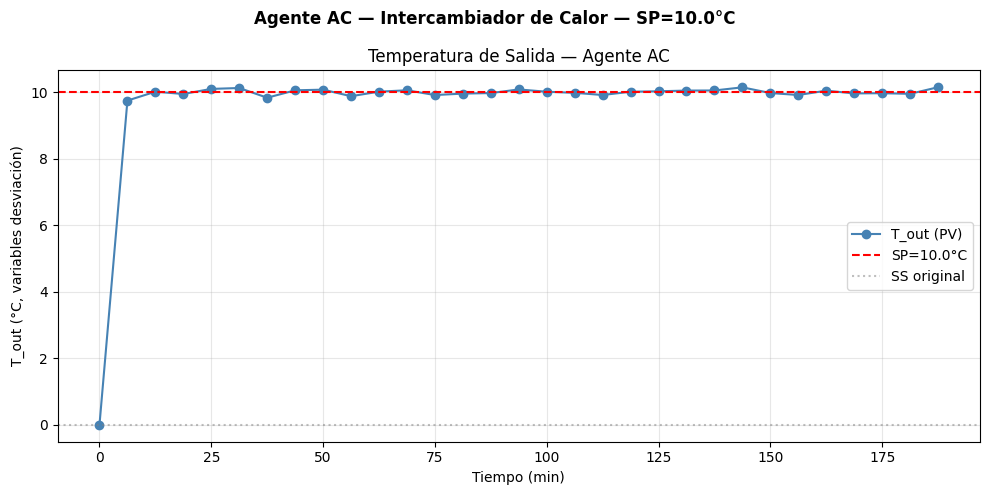

In [10]:
# ============ GRAFICAR ============
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

time_steps = np.arange(len(traj_T)) * INNER_STEPS * DT  # tiempo en minutos
ax.plot(time_steps, traj_T, marker='o', color='steelblue', label='T_out (PV)')
ax.axhline(T_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_sp}°C')
ax.axhline(0.0, color='gray', linestyle=':', alpha=0.5, label='SS original')
ax.set_title('Temperatura de Salida — Agente AC')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('T_out (°C, variables desviación)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Agente AC — Intercambiador de Calor — SP={T_sp}°C', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_ac_heatexchanger.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparación con Baselines del Informe 2013

In [11]:
# Parámetros del proceso
K_proc = 11.2455    # Ganancia estática (°C/mA)
tau_proc = 0.405    # Constante de tiempo (min)
theta_proc = 0.125  # Tiempo muerto (min)

# Parámetros de la perturbación (Ensayo 2 del informe)
K_d = 1.0           # Ganancia de perturbación (°C/°C) — del ensayo 2
tau_d = 0.915       # Constante de tiempo de perturbación (min)
theta_d = 0.315     # Tiempo muerto de perturbación (min)

T_sp_eval = 10.0    # °C en variables desviación

In [12]:
def run_baseline_pid_hx(hx, T_sp, Kp, Ki, Kd, n_steps=2000):
    """Simula el intercambiador con PID feedback fijo."""
    hx.reset()
    integral = 0.0
    prev_err = 0.0
    dt = hx.dt
    t_hist = []

    for _ in range(n_steps):
        meas = hx.get_measurements()
        err = T_sp - meas['T_out']
        integral += err * dt
        deriv = (err - prev_err) / dt
        u = Kp * err + Ki * integral + Kd * deriv
        u = np.clip(u, -8.0, 8.0)
        prev_err = err
        pvs = hx.simulate_step_multi([u], dt)
        t_hist.append(pvs[0])

    return t_hist


def run_feedback_feedforward(hx, T_sp, Kp, Ki, Kd, n_steps=2000, perturb_step=None, delta_T_in=0.0):
    """
    Simula el intercambiador con PID feedback + controlador feedforward.

    Feedforward del informe 2013:
        Gff(s) = -1.7785e-2 * e^(-0.19s) * (0.405s+1) / (0.915s+1)

    Discretizado como filtro de primer orden con delay.
    """
    hx.reset()
    integral = 0.0
    prev_err = 0.0
    dt = hx.dt
    t_hist = []

    # Feedforward: discretizar Gff como filtro de primer orden
    # Gff = Kff * (tau_p * s + 1) / (tau_d * s + 1) * e^(-theta_ff * s)
    Kff = -1.7785e-2
    tau_ff_num = 0.405    # τ del numerador (= τ del proceso)
    tau_ff_den = 0.915    # τ del denominador (= τ de la perturbación)
    theta_ff = 0.19       # Tiempo muerto del feedforward

    # Discretización del filtro (1er orden): y[k] = alpha * y[k-1] + beta * (x[k] - gamma * x[k-1])
    alpha = np.exp(-dt / tau_ff_den)
    # Para el lead-lag: H(s) = Kff * (tau_n*s + 1)/(tau_d*s + 1)
    # Tustin: complicado. Usamos matched: y[k] = alpha*y[k-1] + Kff*(1-alpha)*(x[k] + (tau_ff_num/dt - 1)*(x[k]-x[k-1]))
    # Simplificación: separar en ganancia estática + lead-lag

    # Método simple: filtro de primer orden para Kff/(tau_d*s+1) + derivativo para tau_n
    ff_state = 0.0  # Estado del filtro

    # Buffer de delay para el feedforward
    delay_steps_ff = max(1, round(theta_ff / dt))
    T_in_buffer = [0.0] * (delay_steps_ff + 1)

    # Señal de perturbación
    T_in_deviation = 0.0  # Perturbación en T_in (variables desviación)
    prev_T_in = 0.0

    for step in range(n_steps):
        # Aplicar perturbación
        if perturb_step is not None and step == perturb_step:
            T_in_deviation = delta_T_in

        # Buffer de delay del feedforward
        T_in_buffer.append(T_in_deviation)
        if len(T_in_buffer) > delay_steps_ff + 1:
            T_in_buffer.pop(0)
        T_in_delayed = T_in_buffer[0]

        # Feedforward: filtro lead-lag discreto
        # Lead-lag: Kff * (tau_n*s+1)/(tau_d*s+1)
        # Discreto (Euler): ff_state += dt/tau_d * (-ff_state + Kff * T_in_delayed)
        # Con lead: añadir término derivativo del input
        ff_input = T_in_delayed
        ff_deriv = (T_in_delayed - prev_T_in) / dt if step > 0 else 0.0

        # Filtro de primer orden sobre la entrada
        ff_state += (dt / tau_ff_den) * (-ff_state + Kff * ff_input + Kff * tau_ff_num * ff_deriv)
        u_ff = ff_state
        prev_T_in = T_in_delayed

        # Feedback PID
        meas = hx.get_measurements()
        err = T_sp - meas['T_out']
        integral += err * dt
        deriv = (err - prev_err) / dt
        u_fb = Kp * err + Ki * integral + Kd * deriv
        prev_err = err

        # Señal total
        u_total = u_fb + u_ff
        u_total = np.clip(u_total, -8.0, 8.0)

        # Simular — aplicar perturbación directamente al simulador
        if perturb_step is not None and step == perturb_step:
            hx.set_disturbance(delta_T_in=delta_T_in)

        pvs = hx.simulate_step_multi([u_total], dt)
        t_hist.append(pvs[0])

    return t_hist

In [13]:
# ============ CORRER BASELINES ============
hx_bl = HeatExchangerSimulator(dt=DT, control_limits=((-8.0, 8.0),))

# 1) PID IMC con λ=1 (el que mejor funcionó en el diagnóstico)
Kp_imc = (1/K_proc) * tau_proc / (tau_proc + 1)
Ki_imc = 1 / ((tau_proc + 1) * K_proc)
t_imc = run_baseline_pid_hx(hx_bl, T_sp_eval, Kp=Kp_imc, Ki=Ki_imc, Kd=0.0)

# 2) PI moderado (del diagnóstico: Kp=0.05, Ki=0.1)
t_pi_mod = run_baseline_pid_hx(hx_bl, T_sp_eval, Kp=0.05, Ki=0.1, Kd=0.0)

# 3) PI suave (del diagnóstico: Kp=0.02, Ki=0.05)
t_pi_suave = run_baseline_pid_hx(hx_bl, T_sp_eval, Kp=0.02, Ki=0.05, Kd=0.0)

print(f'IMC λ=1:    Kp={Kp_imc:.4f}, Ki={Ki_imc:.4f} → T_final={t_imc[-1]:.3f}°C (err={abs(t_imc[-1]-T_sp_eval):.4f})')
print(f'PI moderado: Kp=0.05, Ki=0.10 → T_final={t_pi_mod[-1]:.3f}°C (err={abs(t_pi_mod[-1]-T_sp_eval):.4f})')
print(f'PI suave:    Kp=0.02, Ki=0.05 → T_final={t_pi_suave[-1]:.3f}°C (err={abs(t_pi_suave[-1]-T_sp_eval):.4f})')

IMC λ=1:    Kp=0.0256, Ki=0.0633 → T_final=10.002°C (err=0.0023)
PI moderado: Kp=0.05, Ki=0.10 → T_final=9.983°C (err=0.0172)
PI suave:    Kp=0.02, Ki=0.05 → T_final=9.971°C (err=0.0293)


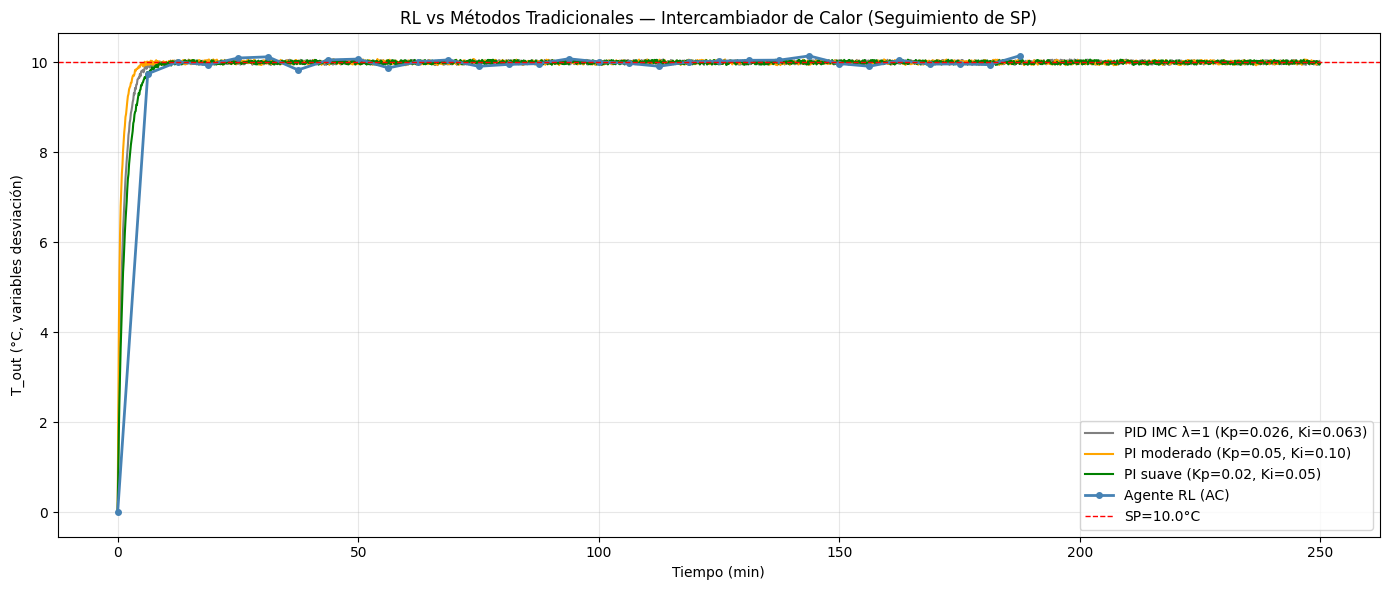

In [14]:
# ============ GRAFICAR COMPARACIÓN CON RL ============
time_min = np.arange(len(t_imc)) * DT
time_rl = np.arange(len(traj_T)) * INNER_STEPS * DT

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

ax.plot(time_min, t_imc, label=f'PID IMC λ=1 (Kp={Kp_imc:.3f}, Ki={Ki_imc:.3f})', color='gray', linewidth=1.5)
ax.plot(time_min, t_pi_mod, label='PI moderado (Kp=0.05, Ki=0.10)', color='orange', linewidth=1.5)
ax.plot(time_min, t_pi_suave, label='PI suave (Kp=0.02, Ki=0.05)', color='green', linewidth=1.5)
ax.plot(time_rl, traj_T, label='Agente RL (AC)', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axhline(T_sp_eval, color='red', linestyle='--', linewidth=1, label=f'SP={T_sp_eval}°C')
ax.set_title('RL vs Métodos Tradicionales — Intercambiador de Calor (Seguimiento de SP)')
ax.set_xlabel('Tiempo (min)')
ax.set_ylabel('T_out (°C, variables desviación)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rl_vs_traditional_hx_corregido.png', dpi=150, bbox_inches='tight')
plt.show()

## Test perturbacion feedback + feedforward

Perturbación aplicada: ΔT_in = 15.0 °C
Perturbación aplicada: ΔT_in = 15.0 °C
Perturbación aplicada: ΔT_in = 15.0 °C
=== Resumen de rechazo de perturbación ===
Feedback solo:        err_max=5.114°C, err_final=0.0244°C
Feedback+Feedforward: err_max=5.163°C, err_final=0.0193°C
Agente RL dinámico:   err_max=0.178°C, err_final=0.0092°C


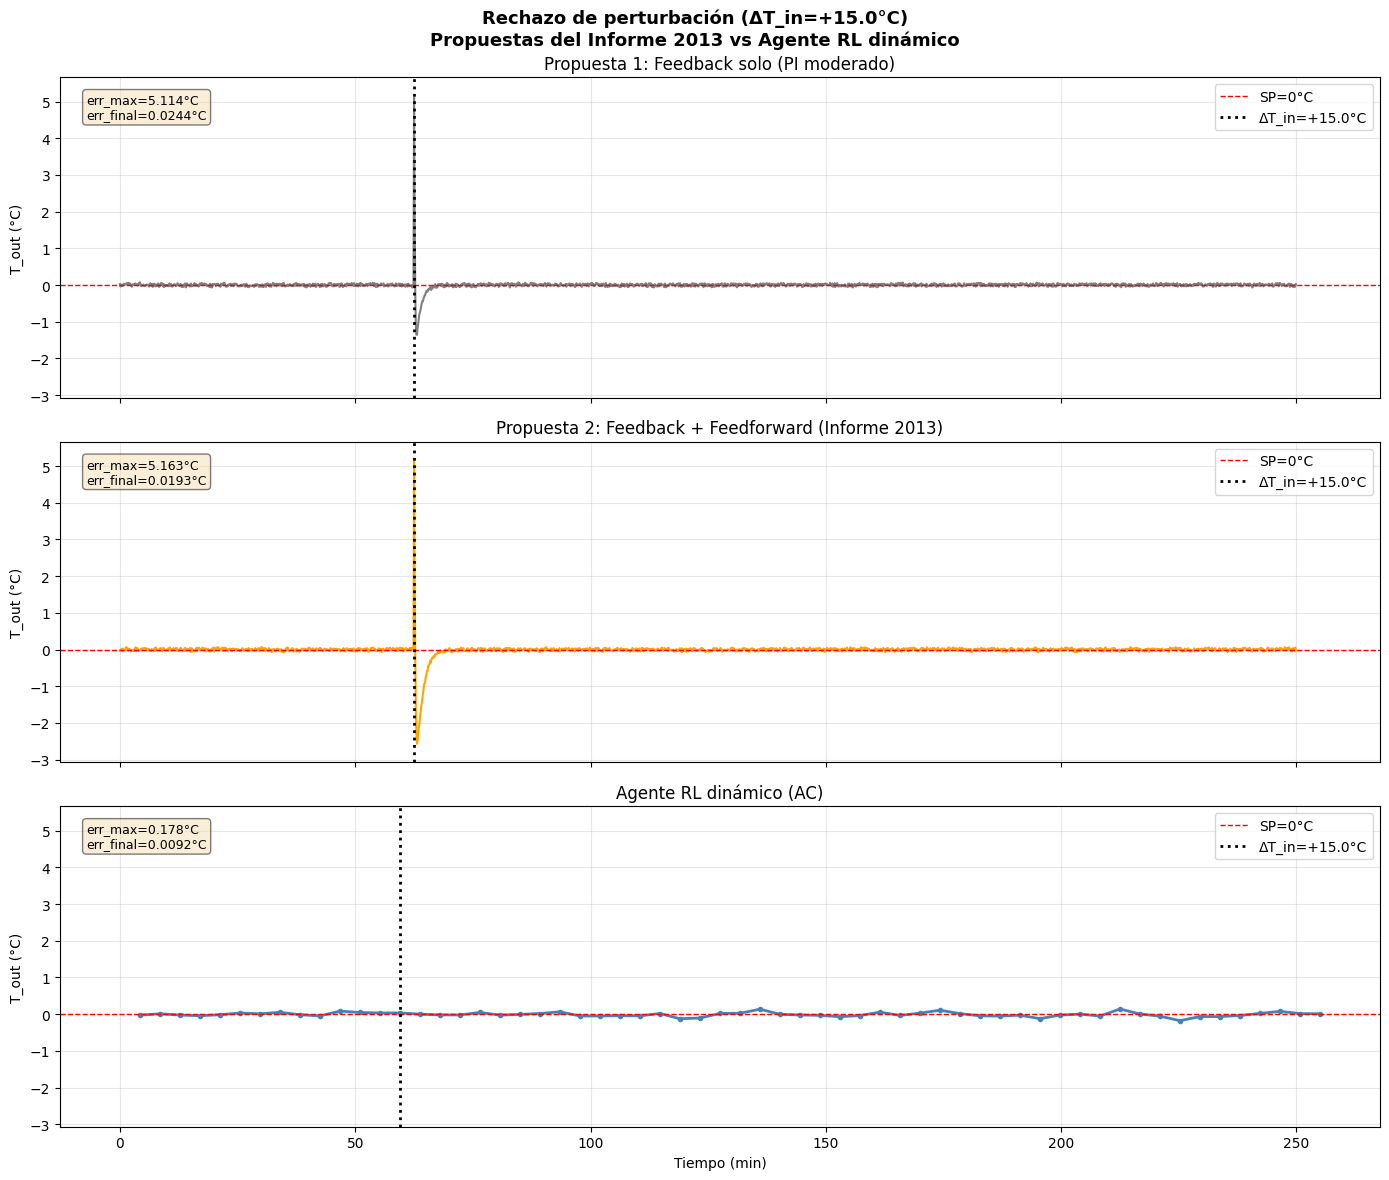

In [15]:

N_STEPS_PERT = 2000
PERTURB_STEP = 500  # Perturbación a los 62.5 min
DELTA_T_IN = 15.0   # °C


# --- 1) Feedback solo (PI moderado) ---
hx_fb = HeatExchangerSimulator(dt=DT, control_limits=((-8.0, 8.0),))
hx_fb.reset()
integral_fb = 0.0
prev_err_fb = 0.0
t_fb = []

for step in range(N_STEPS_PERT):
    if step == PERTURB_STEP:
        hx_fb.set_disturbance(delta_T_in=DELTA_T_IN)
    meas = hx_fb.get_measurements()
    err = 0.0 - meas['T_out']
    integral_fb += err * DT
    deriv = (err - prev_err_fb) / DT
    u = 0.05 * err + 0.1 * integral_fb
    u = np.clip(u, -8.0, 8.0)
    prev_err_fb = err
    pvs = hx_fb.simulate_step_multi([u], DT)
    t_fb.append(pvs[0])


# --- 2) Feedback + Feedforward (Informe 2013) ---
hx_fbff = HeatExchangerSimulator(dt=DT, control_limits=((-8.0, 8.0),))
hx_fbff.reset()
integral_fbff = 0.0
prev_err_fbff = 0.0
t_fbff = []

# Feedforward: Gff = -Kd/Kp * (τ_p*s+1)/(τ_d*s+1) * e^(-(θd-θp)*s)
# Del informe: Gff = -1.7785e-2 * e^(-0.19s) * (0.405s+1) / (0.915s+1)
Kff = -1.7785e-2
tau_ff_num = 0.405
tau_ff_den = 0.915
theta_ff = 0.19
delay_steps_ff = max(1, round(theta_ff / DT))
T_in_buffer_ff = [0.0] * (delay_steps_ff + 1)
ff_state = 0.0
prev_T_in_ff = 0.0
T_in_dev = 0.0

for step in range(N_STEPS_PERT):
    if step == PERTURB_STEP:
        T_in_dev = DELTA_T_IN
        hx_fbff.set_disturbance(delta_T_in=DELTA_T_IN)

    # Feedforward: el controlador FF mide T_in directamente
    # Delay del feedforward
    T_in_buffer_ff.append(T_in_dev)
    if len(T_in_buffer_ff) > delay_steps_ff + 1:
        T_in_buffer_ff.pop(0)
    T_in_delayed = T_in_buffer_ff[0]

    # Lead-lag discreto: Gff(s) = Kff * (tau_n*s+1)/(tau_d*s+1)
    ff_deriv = (T_in_delayed - prev_T_in_ff) / DT if step > 0 else 0.0
    ff_state += (DT / tau_ff_den) * (-ff_state + Kff * T_in_delayed + Kff * tau_ff_num * ff_deriv)
    u_ff = ff_state
    prev_T_in_ff = T_in_delayed

    # Feedback PID
    meas = hx_fbff.get_measurements()
    err = 0.0 - meas['T_out']
    integral_fbff += err * DT
    deriv = (err - prev_err_fbff) / DT
    u_fb = 0.05 * err + 0.1 * integral_fbff
    prev_err_fbff = err

    u_total = np.clip(u_fb + u_ff, -8.0, 8.0)
    pvs = hx_fbff.simulate_step_multi([u_total], DT)
    t_fbff.append(pvs[0])


# --- 3) Agente RL dinámico (loop directo) ---
hx_rl = HeatExchangerSimulator(dt=DT, control_limits=((-8.0, 8.0),))
hx_rl.reset()

pid_rl = PIDController(kp=0.05, ki=0.1, kd=0.0, dt=DT, output_limits=(-8.0, 8.0))
pid_rl.integral = 0.0

apply_action_pert = ApplyAction(
    delta_percent_ctrl=0.2,
    pid_limits=[(0.005, 0.2), (0.0, 0.5), (0.0, 0.1)],
    manipulable_ranges=MANIPULABLE_RANGES
)

T_sp_rl = 0.0
pvs_rl = hx_rl.get_initial_pvs()
error_integral_rl = 0.0
error_prev_rl = T_sp_rl - pvs_rl[0]
t_rl_dyn = []

N_AGENT_STEPS = 60
INNER_STEPS_PERT = 34
PERTURB_AGENT_STEP = int(PERTURB_STEP / INNER_STEPS_PERT)

for step in range(N_AGENT_STEPS):
    if step == PERTURB_AGENT_STEP:
        hx_rl.set_disturbance(delta_T_in=DELTA_T_IN)

    error = T_sp_rl - pvs_rl[0]
    error_integral_rl += error * DT
    error_derivative = error - error_prev_rl
    error_prev_rl = error

    state = np.array([
        pvs_rl[0], T_sp_rl, error, error_integral_rl, error_derivative,
    ], dtype=np.float32)

    action = agent_eval.select_action(state, training=False)
    pid_params = apply_action_pert.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(pid_rl.kp, pid_rl.ki, pid_rl.kd)]
    )
    kp, ki, kd = pid_params[0]
    pid_rl.kp = kp
    pid_rl.ki = ki
    pid_rl.kd = kd

    for _ in range(INNER_STEPS_PERT):
        meas = hx_rl.get_measurements()
        u_out = pid_rl.compute(setpoint=T_sp_rl, process_value=meas['T_out'])
        pvs_new = hx_rl.simulate_step_multi([u_out], DT)

    pvs_rl = [pvs_new[0]]
    t_rl_dyn.append(pvs_rl[0])


# ============ MÉTRICAS ============
post_fb = np.array(t_fb[PERTURB_STEP:])
post_fbff = np.array(t_fbff[PERTURB_STEP:])
post_rl = np.array(t_rl_dyn[PERTURB_AGENT_STEP:])

print('=== Resumen de rechazo de perturbación ===')
print(f'Feedback solo:        err_max={np.max(np.abs(post_fb)):.3f}°C, err_final={abs(t_fb[-1]):.4f}°C')
print(f'Feedback+Feedforward: err_max={np.max(np.abs(post_fbff)):.3f}°C, err_final={abs(t_fbff[-1]):.4f}°C')
print(f'Agente RL dinámico:   err_max={np.max(np.abs(post_rl)):.3f}°C, err_final={abs(t_rl_dyn[-1]):.4f}°C')


# ============ GRAFICAR A MISMA ESCALA ============
time_pert = np.arange(N_STEPS_PERT) * DT
time_rl = np.arange(1, N_AGENT_STEPS + 1) * INNER_STEPS_PERT * DT

# Determinar escala Y común
all_data = list(t_fb) + list(t_fbff) + list(t_rl_dyn)
y_min = min(all_data) - 0.5
y_max = max(all_data) + 0.5

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Subplot 1: Feedback solo
axes[0].plot(time_pert, t_fb, color='gray', linewidth=1.5)
axes[0].axhline(0.0, color='red', linestyle='--', linewidth=1, label='SP=0°C')
axes[0].axvline(PERTURB_STEP * DT, color='black', linestyle=':', linewidth=2, label=f'ΔT_in=+{DELTA_T_IN}°C')
axes[0].set_title('Propuesta 1: Feedback solo (PI moderado)')
axes[0].set_ylabel('T_out (°C)')
axes[0].set_ylim(y_min, y_max)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.95, f'err_max={np.max(np.abs(post_fb)):.3f}°C\nerr_final={abs(t_fb[-1]):.4f}°C',
             transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 2: Feedback + Feedforward
axes[1].plot(time_pert, t_fbff, color='orange', linewidth=1.5)
axes[1].axhline(0.0, color='red', linestyle='--', linewidth=1, label='SP=0°C')
axes[1].axvline(PERTURB_STEP * DT, color='black', linestyle=':', linewidth=2, label=f'ΔT_in=+{DELTA_T_IN}°C')
axes[1].set_title('Propuesta 2: Feedback + Feedforward (Informe 2013)')
axes[1].set_ylabel('T_out (°C)')
axes[1].set_ylim(y_min, y_max)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.95, f'err_max={np.max(np.abs(post_fbff)):.3f}°C\nerr_final={abs(t_fbff[-1]):.4f}°C',
             transform=axes[1].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 3: Agente RL dinámico
axes[2].plot(time_rl, t_rl_dyn, color='steelblue', linewidth=2, marker='o', markersize=3)
axes[2].axhline(0.0, color='red', linestyle='--', linewidth=1, label='SP=0°C')
axes[2].axvline(PERTURB_AGENT_STEP * INNER_STEPS_PERT * DT, color='black', linestyle=':', linewidth=2, label=f'ΔT_in=+{DELTA_T_IN}°C')
axes[2].set_title('Agente RL dinámico (AC)')
axes[2].set_ylabel('T_out (°C)')
axes[2].set_xlabel('Tiempo (min)')
axes[2].set_ylim(y_min, y_max)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].text(0.02, 0.95, f'err_max={np.max(np.abs(post_rl)):.3f}°C\nerr_final={abs(t_rl_dyn[-1]):.4f}°C',
             transform=axes[2].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Rechazo de perturbación (ΔT_in=+{DELTA_T_IN}°C)\nPropuestas del Informe 2013 vs Agente RL dinámico',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('perturbacion_3propuestas_hx_corregido.png', dpi=150, bbox_inches='tight')
plt.show()